# Fashion Forward Forecasting

StyleSense needs a reliable way to infer whether a customer would recommend a
product when the recommendation flag is missing. This notebook builds and
evaluates a complete machine learning pipeline that uses review text, customer
age, product metadata, and feedback counts to predict `Recommended IND`.

The central modeling requirement is that preprocessing and prediction happen in
one reusable scikit-learn pipeline, so the same object can be used for training
and future inference without data leakage.

## Project Plan

1. Load and validate the review dataset.
2. Explore target balance, feature types, and text length patterns.
3. Split the data into stratified train and test sets before fitting any model.
4. Build a baseline classifier for comparison.
5. Build a full pipeline for numeric, categorical, and text features.
6. Tune the pipeline with cross-validation.
7. Evaluate the final model on the held-out test set.
8. Demonstrate inference on new review records.

## Setup

The notebook uses only the project environment dependencies: pandas, numpy,
matplotlib, seaborn, and scikit-learn. A fixed random seed keeps the split and
cross-validation reproducible.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


RANDOM_STATE = 27
TARGET_COLUMN = "Recommended IND"

DATA_PATH = Path("data/reviews.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("4_Data_Science_Pipelines/project/data/reviews.csv")

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

## Load Data

The dataset is anonymized and includes numeric, categorical, and text features.
The target column is `Recommended IND`, where `1` means the customer recommends
the product and `0` means they do not.

In [2]:
reviews = pd.read_csv(DATA_PATH)

display(
    pd.DataFrame(
        {
            "rows": [reviews.shape[0]],
            "columns": [reviews.shape[1]],
            "duplicate_rows": [reviews.duplicated().sum()],
        }
    )
)
display(reviews.head())

,rows,columns,duplicate_rows
0,18442,9,0


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a ...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with t...,1,General Petite,Tops,Knits,1


## Data Validation

The pipeline will still include imputers even though this copy of the data has
no missing values. That makes the fitted model safer for future reviews where
fields such as `Title`, `Review Text`, or product metadata may be absent.

In [3]:
required_columns = [
    "Clothing ID",
    "Age",
    "Title",
    "Review Text",
    "Positive Feedback Count",
    "Division Name",
    "Department Name",
    "Class Name",
    TARGET_COLUMN,
]

missing_columns = sorted(set(required_columns) - set(reviews.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

target_values = set(reviews[TARGET_COLUMN].dropna().unique())
if not target_values.issubset({0, 1}):
    raise ValueError(f"Unexpected target values: {target_values}")

schema_summary = pd.DataFrame(
    {
        "dtype": reviews.dtypes.astype(str),
        "missing": reviews.isna().sum(),
        "missing_rate": reviews.isna().mean(),
        "unique_values": reviews.nunique(dropna=False),
    }
)
display(schema_summary)

,dtype,missing,missing_rate,unique_values
Clothing ID,int64,0,0.0,531
Age,int64,0,0.0,77
Title,object,0,0.0,13142
Review Text,object,0,0.0,18439
Positive Feedback Count,int64,0,0.0,79
Division Name,object,0,0.0,2
Department Name,object,0,0.0,6
Class Name,object,0,0.0,14
Recommended IND,int64,0,0.0,2


## Exploratory Data Analysis

The target is imbalanced: most customers recommend the item. Evaluation should
therefore include metrics such as balanced accuracy, macro F1, precision, and
recall in addition to accuracy.

,recommended,count,rate
0,1,15053,0.816235
1,0,3389,0.183765


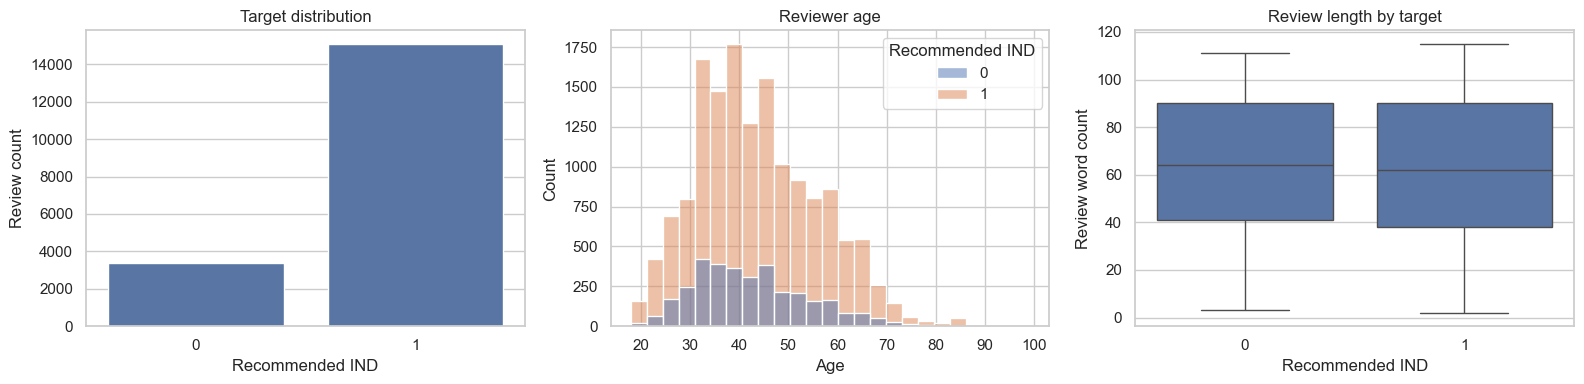

In [4]:
eda_reviews = reviews.assign(
    title_word_count=reviews["Title"].fillna("").str.split().str.len(),
    review_word_count=reviews["Review Text"].fillna("").str.split().str.len(),
    review_char_count=reviews["Review Text"].fillna("").str.len(),
)

target_summary = (
    reviews[TARGET_COLUMN]
    .value_counts()
    .rename_axis("recommended")
    .reset_index(name="count")
)
target_summary["rate"] = target_summary["count"] / len(reviews)
display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=reviews, x=TARGET_COLUMN, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("Recommended IND")
axes[0].set_ylabel("Review count")

sns.histplot(data=reviews, x="Age", hue=TARGET_COLUMN, bins=25, ax=axes[1])
axes[1].set_title("Reviewer age")
axes[1].set_xlabel("Age")

sns.boxplot(data=eda_reviews, x=TARGET_COLUMN, y="review_word_count", ax=axes[2])
axes[2].set_title("Review length by target")
axes[2].set_xlabel("Recommended IND")
axes[2].set_ylabel("Review word count")

plt.tight_layout()
plt.show()

In [5]:
category_summary = (
    reviews.groupby(["Department Name", "Class Name"], observed=True)
    .agg(
        reviews=(TARGET_COLUMN, "size"),
        recommendation_rate=(TARGET_COLUMN, "mean"),
        median_age=("Age", "median"),
        median_positive_feedback=("Positive Feedback Count", "median"),
    )
    .query("reviews >= 100")
    .sort_values(["recommendation_rate", "reviews"], ascending=[False, False])
)

display(category_summary.head(10))
display(category_summary.tail(10))

reviews  recommendation_rate  median_age  \
Department Name Class Name                                             
Bottoms         Jeans           970             0.876289        42.0   
Jackets         Jackets         598             0.849498        42.0   
Bottoms         Skirts          796             0.847990        41.0   
                Pants          1157             0.840968        42.0   
Intimate        Lounge          188             0.835106        40.5   
Tops            Fine gauge      927             0.834951        44.0   
Bottoms         Shorts          260             0.830769        39.0   
Jackets         Outerwear       281             0.822064        41.0   
Tops            Blouses        2587             0.809432        43.0   
                Knits          3981             0.806330        42.0   

                            median_positive_feedback  
Department Name Class Name                            
Bottoms         Jeans                            1.0  
Jackets         Jackets                          1.0  
Bottoms         Skirts                           1.0  
                Pants                            1.0  
Intimate        Lounge                           1.0  
Tops            Fine gauge                       0.0  
Bottoms         Shorts                           1.0  
Jackets         Outerwear                        1.0  
Tops            Blouses                          1.0  
                Knits                            0.0

reviews  recommendation_rate  median_age  \
Department Name Class Name                                             
Bottoms         Pants          1157             0.840968        42.0   
Intimate        Lounge          188             0.835106        40.5   
Tops            Fine gauge      927             0.834951        44.0   
Bottoms         Shorts          260             0.830769        39.0   
Jackets         Outerwear       281             0.822064        41.0   
Tops            Blouses        2587             0.809432        43.0   
                Knits          3981             0.806330        42.0   
Dresses         Dresses        5371             0.803202        40.0   
Tops            Sweaters       1218             0.795567        44.0   
Trend           Trend           107             0.757009        43.0   

                            median_positive_feedback  
Department Name Class Name                            
Bottoms         Pants                            1.0  
Intimate        Lounge                           1.0  
Tops            Fine gauge                       0.0  
Bottoms         Shorts                           1.0  
Jackets         Outerwear                        1.0  
Tops            Blouses                          1.0  
                Knits                            0.0  
Dresses         Dresses                          1.0  
Tops            Sweaters                         1.0  
Trend           Trend                            2.0

## Train/Test Split

The split is stratified so both classes remain represented in the train and test
sets. All preprocessing, vectorization, encoding, scaling, and model fitting
happen after this split.

In [6]:
feature_columns = [column for column in required_columns if column != TARGET_COLUMN]
X = reviews[feature_columns].copy()
y = reviews[TARGET_COLUMN].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "positive_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
display(split_summary)

,rows,positive_rate
train,14753,0.816241
test,3689,0.816210


## NLP Feature Engineering

`ReviewFeatureBuilder` is part of the sklearn pipeline. It combines title and
review body, normalizes text, tokenizes the review for engineered text features,
and creates compact sentiment-count signals. Keeping this logic inside the
pipeline ensures training and inference use the same transformations.

In [7]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")

POSITIVE_WORDS = frozenset(
    {
        "amazing",
        "awesome",
        "beautiful",
        "best",
        "comfortable",
        "cute",
        "excellent",
        "favorite",
        "flattering",
        "great",
        "happy",
        "love",
        "loved",
        "lovely",
        "perfect",
        "pretty",
        "recommend",
        "soft",
        "stunning",
        "wonderful",
    }
)

NEGATIVE_WORDS = frozenset(
    {
        "awful",
        "bad",
        "cheap",
        "disappointed",
        "disappointing",
        "hate",
        "hated",
        "poor",
        "problem",
        "return",
        "returned",
        "scratchy",
        "small",
        "terrible",
        "tight",
        "uncomfortable",
        "unflattering",
        "weird",
        "worse",
        "worst",
    }
)


def normalize_text(text: object) -> str:
    """Normalize review text before vectorization."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-zA-Z']+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize_text(text: object) -> list[str]:
    """Tokenize normalized text into alphabetic word tokens."""
    return TOKEN_PATTERN.findall(normalize_text(text))


class ReviewFeatureBuilder(BaseEstimator, TransformerMixin):
    """Create model-ready text and text-derived numeric features."""

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "ReviewFeatureBuilder":
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transformed = X.copy()

        title = X_transformed["Title"].fillna("").astype(str)
        review = X_transformed["Review Text"].fillna("").astype(str)
        combined_text = (title + ". " + review).map(normalize_text)
        token_lists = combined_text.map(TOKEN_PATTERN.findall)

        word_count = token_lists.map(len).astype(float)
        positive_count = token_lists.map(
            lambda tokens: sum(token in POSITIVE_WORDS for token in tokens)
        ).astype(float)
        negative_count = token_lists.map(
            lambda tokens: sum(token in NEGATIVE_WORDS for token in tokens)
        ).astype(float)
        safe_word_count = word_count.replace(0, np.nan)

        feedback_count = pd.to_numeric(
            X_transformed["Positive Feedback Count"], errors="coerce"
        )

        X_transformed["combined_review_text"] = combined_text
        X_transformed["review_word_count"] = word_count
        X_transformed["review_char_count"] = combined_text.str.len().astype(float)
        X_transformed["title_word_count"] = title.map(tokenize_text).map(len).astype(float)
        X_transformed["exclamation_count"] = review.str.count("!").astype(float)
        X_transformed["question_count"] = review.str.count(r"\?").astype(float)
        X_transformed["positive_word_count"] = positive_count
        X_transformed["negative_word_count"] = negative_count
        X_transformed["sentiment_balance"] = (
            (positive_count - negative_count) / safe_word_count
        ).fillna(0)
        X_transformed["positive_feedback_log"] = np.log1p(feedback_count)

        return X_transformed

## Pipeline Design

The pipeline treats each data type separately:

- numeric columns are imputed and scaled;
- categorical columns are imputed and one-hot encoded;
- combined review text is normalized, tokenized, and vectorized with TF-IDF;
- the classifier is trained on the full transformed feature matrix.

In [8]:
NUMERIC_FEATURES = [
    "Age",
    "Positive Feedback Count",
    "review_word_count",
    "review_char_count",
    "title_word_count",
    "exclamation_count",
    "question_count",
    "positive_word_count",
    "negative_word_count",
    "sentiment_balance",
    "positive_feedback_log",
]

CATEGORICAL_FEATURES = [
    "Clothing ID",
    "Division Name",
    "Department Name",
    "Class Name",
]

TEXT_FEATURE = "combined_review_text"


def build_preprocessor() -> ColumnTransformer:
    """Build preprocessing for numeric, categorical, and text columns."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=5,
                    sparse_output=True,
                ),
            ),
        ]
    )

    text_vectorizer = TfidfVectorizer(
        preprocessor=normalize_text,
        stop_words="english",
        sublinear_tf=True,
        min_df=3,
        max_features=10_000,
        ngram_range=(1, 2),
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("text", text_vectorizer, TEXT_FEATURE),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )


def build_model_pipeline(model: object | None = None) -> Pipeline:
    """Build a complete training and inference pipeline."""
    if model is None:
        model = LogisticRegression(
            max_iter=2_000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    return Pipeline(
        steps=[
            ("feature_builder", ReviewFeatureBuilder()),
            ("preprocess", build_preprocessor()),
            ("model", model),
        ]
    )


model_pipeline = build_model_pipeline()
model_pipeline

Pipeline(steps=[('feature_builder', ReviewFeatureBuilder()),
                ('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['Age',
                                                   'Positive Feedback Count',
                                                   'review_word_count',
                                                   'review_char_count',
                                                   'title_word_count',
                                                   'exclamation_count',
                                                   'question_count',
                                                   '...
                                                  ['Clothing ID',
                                                   'Division Name',
                                                   'Department Name',
                                                   'Class Name']),
                                                 ('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  preprocessor=<function normalize_text at 0x11ec7f600>,
                                                                  stop_words='english',
                                                                  sublinear_tf=True),
                                                  'combined_review_text')])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=27, solver='liblinear'))])

## Evaluation Helpers

The helper below reports multiple classification metrics. Macro F1 and balanced
accuracy are especially useful because the target is imbalanced.

In [9]:
def evaluate_classifier(
    name: str,
    estimator: Pipeline,
    X_data: pd.DataFrame,
    y_true: pd.Series,
) -> dict[str, float | str]:
    """Evaluate a fitted classifier and return a compact metrics dictionary."""
    y_pred = estimator.predict(X_data)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_data)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        metrics["roc_auc"] = np.nan

    return metrics


def display_classification_report(
    estimator: Pipeline,
    X_data: pd.DataFrame,
    y_true: pd.Series,
) -> pd.DataFrame:
    """Display a formatted sklearn classification report."""
    report = classification_report(
        y_true,
        estimator.predict(X_data),
        output_dict=True,
        zero_division=0,
    )
    report_frame = pd.DataFrame(report).T
    display(report_frame.round(3))
    return report_frame

## Baseline Model

The dummy model predicts the majority class. It sets the minimum bar that the
trained pipeline must clear, and it highlights why accuracy alone is not enough
for this dataset.

In [10]:
baseline_pipeline = build_model_pipeline(
    DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
)
baseline_pipeline.fit(X_train, y_train)

baseline_metrics = evaluate_classifier(
    "dummy_majority",
    baseline_pipeline,
    X_test,
    y_test,
)

display(pd.DataFrame([baseline_metrics]).set_index("model").round(3))

,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,roc_auc
model,,,,,,,
dummy_majority,0.816,0.5,0.816,1.0,0.899,0.449,0.5


## Fine-Tune The Pipeline

`GridSearchCV` tunes text vectorization and logistic regression regularization
inside the full pipeline. Cross-validation sees only the training split, and
the held-out test set remains untouched until final evaluation.

In [11]:
param_grid = {
    "preprocess__text__max_features": [5_000, 10_000],
    "preprocess__text__min_df": [2, 5],
    "preprocess__text__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.5, 1.0, 2.0],
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

display(pd.DataFrame([grid_search.best_params_]))
print(f"Best cross-validation macro F1: {grid_search.best_score_:.3f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,model__C,preprocess__text__max_features,preprocess__text__min_df,preprocess__text__ngram_range
0,2.0,10000,5,"(1, 2)"


Best cross-validation macro F1: 0.827


In [12]:
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_score")
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_preprocess__text__max_features",
            "param_preprocess__text__min_df",
            "param_preprocess__text__ngram_range",
            "param_model__C",
        ]
    ]
)

display(cv_results.head(8).round(3))

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_preprocess__text__max_features,param_preprocess__text__min_df,param_preprocess__text__ngram_range,param_model__C
23,1,0.827,0.002,0.918,10000,5,"(1, 2)",2.0
21,2,0.827,0.002,0.918,10000,2,"(1, 2)",2.0
17,3,0.825,0.004,0.907,5000,2,"(1, 2)",2.0
19,4,0.824,0.005,0.907,5000,5,"(1, 2)",2.0
20,5,0.821,0.003,0.896,10000,2,"(1, 1)",2.0
11,6,0.821,0.006,0.882,5000,5,"(1, 2)",1.0
16,7,0.821,0.002,0.895,5000,2,"(1, 1)",2.0
9,8,0.820,0.005,0.882,5000,2,"(1, 2)",1.0


## Final Test Evaluation

The final model is the best cross-validated pipeline refit on the training data.
It is evaluated once on the held-out test set.

In [13]:
best_pipeline = grid_search.best_estimator_

train_metrics = evaluate_classifier(
    "tuned_logistic_regression_train",
    best_pipeline,
    X_train,
    y_train,
)
test_metrics = evaluate_classifier(
    "tuned_logistic_regression_test",
    best_pipeline,
    X_test,
    y_test,
)

metrics_table = pd.DataFrame(
    [baseline_metrics, train_metrics, test_metrics]
).set_index("model")
display(metrics_table.round(3))

,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,roc_auc
model,,,,,,,
dummy_majority,0.816,0.500,0.816,1.000,0.899,0.449,0.500
tuned_logistic_regression_train,0.941,0.958,0.996,0.931,0.963,0.911,0.987
tuned_logistic_regression_test,0.894,0.872,0.961,0.907,0.933,0.839,0.948


In [14]:
test_report = display_classification_report(best_pipeline, X_test, y_test)

,precision,recall,f1-score,support
0,0.670,0.838,0.744,678.000
1,0.961,0.907,0.933,3011.000
accuracy,0.894,0.894,0.894,0.894
macro avg,0.816,0.872,0.839,3689.000
weighted avg,0.908,0.894,0.899,3689.000


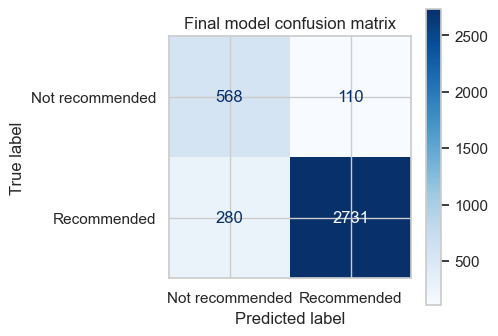

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test,
    display_labels=["Not recommended", "Recommended"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title("Final model confusion matrix")
plt.tight_layout()
plt.show()

## Feature Signals

Logistic regression coefficients provide a lightweight interpretation of which
features push predictions toward recommendation or non-recommendation. These are
associations learned by the model, not causal explanations.

In [16]:
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = best_pipeline.named_steps["model"].coef_[0]

feature_signal = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    }
)

top_positive = (
    feature_signal.sort_values("coefficient", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
top_negative = (
    feature_signal.sort_values("coefficient", ascending=True)
    .head(15)
    .reset_index(drop=True)
)

display(top_positive)
display(top_negative)

,feature,coefficient,absolute_coefficient
0,text__unique,5.389967,5.389967
1,text__small,4.844398,4.844398
2,text__nice,4.175078,4.175078
3,text__compliments,3.975604,3.975604
4,text__fits,3.966499,3.966499
5,text__little,3.965246,3.965246
6,text__casual,3.877778,3.877778
7,text__fun,3.692695,3.692695
8,text__medium,3.528502,3.528502
9,text__gorgeous,3.478391,3.478391


,feature,coefficient,absolute_coefficient
0,text__wanted love,-7.261234,7.261234
1,text__huge,-5.462310,5.462310
2,text__meh,-4.836937,4.836937
3,text__disappointed,-4.734601,4.734601
4,text__returning,-4.298435,4.298435
5,text__odd,-4.041149,4.041149
6,text__strange,-3.942813,3.942813
7,text__unfortunately,-3.813169,3.813169
8,text__fabric,-3.812697,3.812697
9,text__loved,-3.781731,3.781731


## Inference Example

The fitted `best_pipeline` can score new reviews directly. The example below
includes a missing title to show that the pipeline handles future nulls through
its preprocessing steps.

In [17]:
new_reviews = pd.DataFrame(
    [
        {
            "Clothing ID": 1077,
            "Age": 38,
            "Title": None,
            "Review Text": (
                "The dress is flattering, comfortable, and perfect for work. "
                "I would absolutely recommend it."
            ),
            "Positive Feedback Count": 2,
            "Division Name": "General",
            "Department Name": "Dresses",
            "Class Name": "Dresses",
        },
        {
            "Clothing ID": 1049,
            "Age": 51,
            "Title": "Not for me",
            "Review Text": (
                "The fabric felt cheap and the fit was uncomfortable, "
                "so I returned it."
            ),
            "Positive Feedback Count": 0,
            "Division Name": "General Petite",
            "Department Name": "Bottoms",
            "Class Name": "Pants",
        },
    ]
)

new_predictions = best_pipeline.predict(new_reviews)
new_probabilities = best_pipeline.predict_proba(new_reviews)[:, 1]

prediction_output = new_reviews.assign(
    predicted_recommended=new_predictions,
    probability_recommended=new_probabilities,
)
display(prediction_output)

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,predicted_recommended,probability_recommended
0,1077,38,None,"The dress is flattering, comfortable, and perfect for work. I would absolutely recommend it.",2,General,Dresses,Dresses,1,0.995207
1,1049,51,Not for me,"The fabric felt cheap and the fit was uncomfortable, so I returned it.",0,General Petite,Bottoms,Pants,0,0.000548


## Run Summary

This compact summary is useful for updating the README after the notebook is
executed.

In [18]:
run_summary = {
    "rows": int(len(reviews)),
    "features": int(X.shape[1]),
    "positive_rate": float(y.mean()),
    "best_cv_f1_macro": float(grid_search.best_score_),
    "best_params": grid_search.best_params_,
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_balanced_accuracy": float(test_metrics["balanced_accuracy"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
    "test_f1": float(test_metrics["f1"]),
    "test_f1_macro": float(test_metrics["f1_macro"]),
    "test_roc_auc": float(test_metrics["roc_auc"]),
}

print(json.dumps(run_summary, indent=2, default=str))

{
  "rows": 18442,
  "features": 8,
  "positive_rate": 0.8162346817048043,
  "best_cv_f1_macro": 0.8274454277438883,
  "best_params": {
    "model__C": 2.0,
    "preprocess__text__max_features": 10000,
    "preprocess__text__min_df": 5,
    "preprocess__text__ngram_range": [
      1,
      2
    ]
  },
  "test_accuracy": 0.8942802927622662,
  "test_balanced_accuracy": 0.8723828753763242,
  "test_precision": 0.961281239000352,
  "test_recall": 0.9070076386582531,
  "test_f1": 0.9333561175666438,
  "test_f1_macro": 0.8388929998056024,
  "test_roc_auc": 0.9475977463166031
}


## Conclusions

The tuned sklearn pipeline satisfies the project requirements:

- preprocessing, feature engineering, vectorization, tuning, and prediction are
  contained in reusable pipeline objects;
- numeric, categorical, and text data are handled separately and appropriately;
- engineered NLP features complement TF-IDF text vectors;
- hyperparameters are selected with cross-validation on the training set only;
- final evaluation uses the held-out test set and reports metrics beyond
  accuracy.

The main limitation is class imbalance: most reviews are recommendations. The
model is therefore optimized and evaluated with macro F1 and balanced accuracy
so minority-class performance remains visible.